# Loan Analysis - Exploratory Data Analysis

## Introduction

> `LendingClub` is a US peer-to-peer lending company, headquartered in San Francisco, California.
> Since 2007, LendingClub has facilitated more than $50 billion in loans.

**Goal:** Explore the Lending Club dataset, understand feature distributions, and identify patterns that distinguish loans that were fully paid from those that were charged off.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

## Load Data

We load the Lending Club accepted loans dataset and keep only the columns used in our analysis. We also filter to loans with a final status of **Fully Paid** or **Charged Off**.

In [ ]:
data = pd.read_csv("../data/raw/lending_club_loan_two.csv.zip", low_memory=False)

# Filter to final loan statuses only
data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

print(f"Dataset shape: {data.shape}")
data.head()

In [3]:
data.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,1345310.00,1345310.00,1345310.00,1345310.00,1344936.00,1345310.00,1345310.00,1345310.00,1344453.00,1345310.00,1298029.00,1344613.00
mean,14419.97,13.24,438.08,76247.64,18.28,11.59,0.22,16248.11,51.81,24.98,1.67,0.13
std,8717.05,4.77,261.51,69925.10,11.16,5.47,0.60,22328.17,24.52,12.00,2.00,0.38
min,500.00,5.31,4.93,0.00,-1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00
25%,8000.00,9.75,248.48,45780.00,11.79,8.00,0.00,5943.00,33.40,16.00,0.00,0.00
50%,12000.00,12.74,375.43,65000.00,17.61,11.00,0.00,11134.00,52.20,23.00,1.00,0.00
75%,20000.00,15.99,580.73,90000.00,24.06,14.00,0.00,19755.75,70.70,32.00,3.00,0.00
max,40000.00,30.99,1719.83,10999200.00,999.00,90.00,86.00,2904836.00,892.30,176.00,51.00,12.00


# Exploratory Data Analysis

> **OVERALL GOAL:**
> - Get an understanding for which variables are important, view summary statistics, and visualize the data.
> - Clean features and engineer new ones for the model.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             1345310 non-null  float64
 1   term                  1345310 non-null  object 
 2   int_rate              1345310 non-null  float64
 3   installment           1345310 non-null  float64
 4   grade                 1345310 non-null  object 
 5   sub_grade             1345310 non-null  object 
 6   emp_title             1259525 non-null  object 
 7   emp_length            1266799 non-null  object 
 8   home_ownership        1345310 non-null  object 
 9   annual_inc            1345310 non-null  float64
 10  verification_status   1345310 non-null  object 
 11  issue_d               1345310 non-null  object 
 12  loan_status           1345310 non-null  object 
 13  purpose               1345310 non-null  object 
 14  title                 1328650 non-null 

## `loan_status`

> Current status of the loan

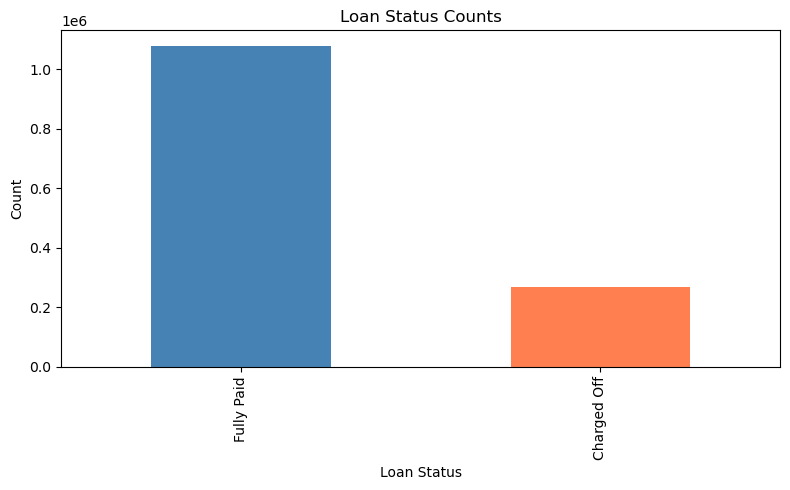

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
data['loan_status'].value_counts().plot.bar(ax=ax, color=['steelblue', 'coral'])
ax.set_title("Loan Status Counts")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

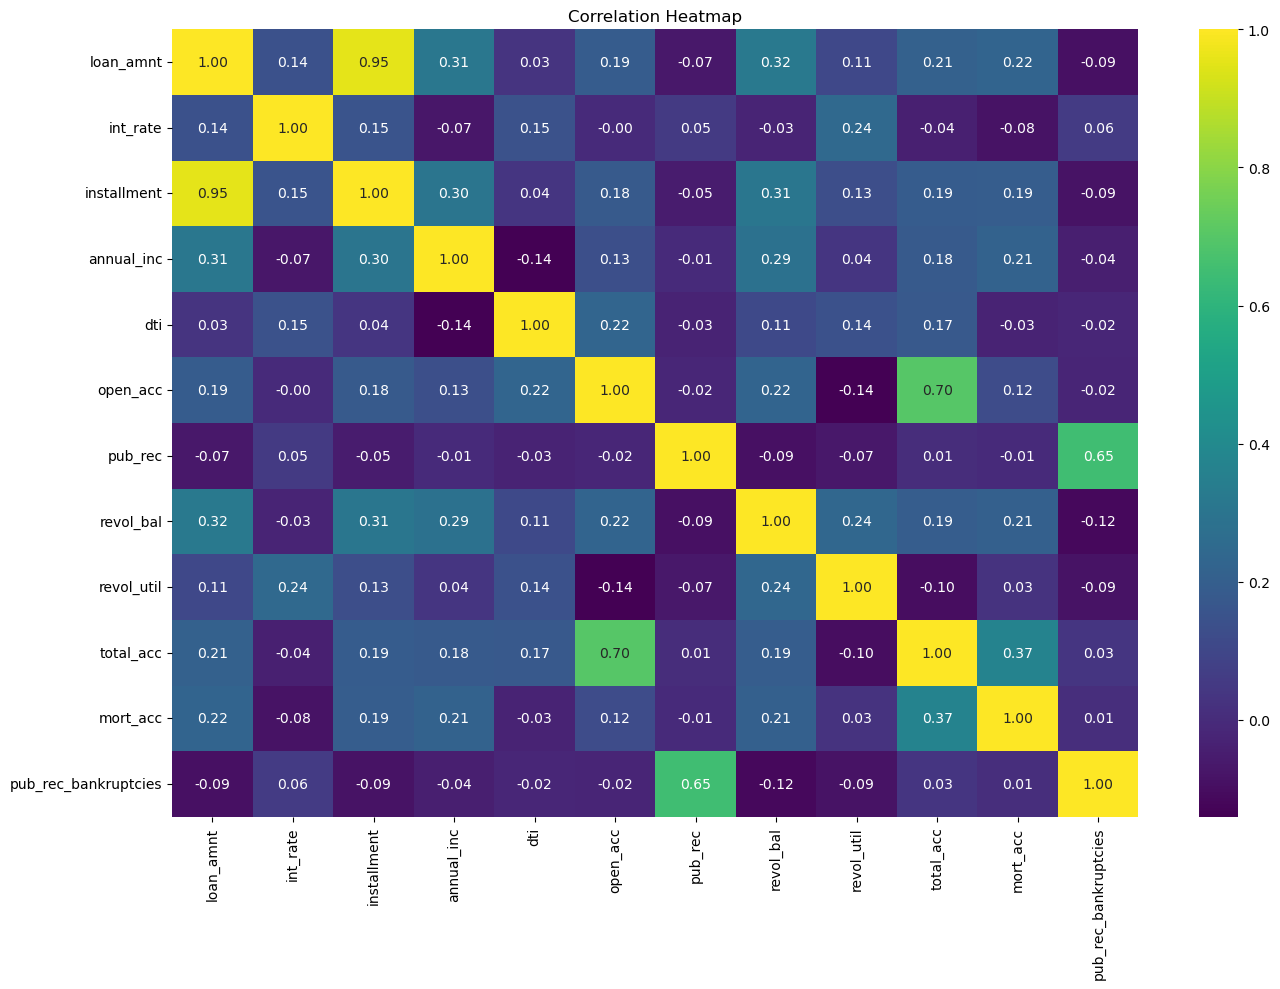

In [6]:
plt.figure(figsize=(14, 10))
numeric_cols = data.select_dtypes(include=[np.number]).columns
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Notice
> We noticed almost perfect correlation between "`loan_amnt`" and the "`installment`" feature. We'll explore these features further.

> - Does this relationship make sense to you?
> - Do we think there is duplicate information here?

## `loan_amnt` & `installment`

> - `installment`: The monthly payment owed by the borrower if the loan originates.
> - `loan_amnt`: The listed amount of the loan applied for by the borrower.

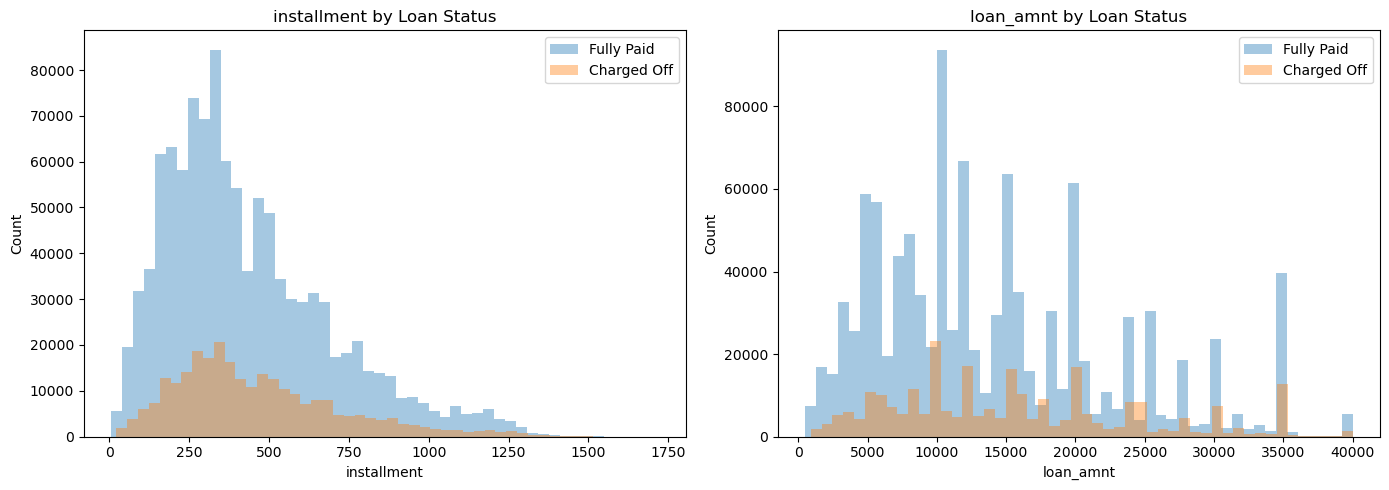

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['installment', 'loan_amnt']):
    for status in ['Fully Paid', 'Charged Off']:
        subset = data[data['loan_status'] == status][col]
        axes[i].hist(subset, bins=50, alpha=0.4, label=status)
    axes[i].set_title(f"{col} by Loan Status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.show()

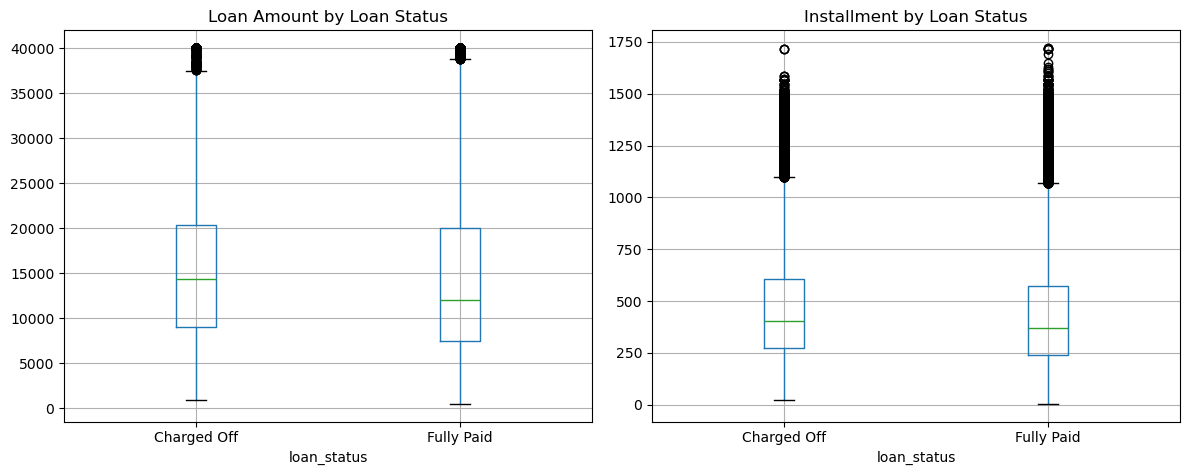

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data.boxplot(column='loan_amnt', by='loan_status', ax=axes[0])
axes[0].set_title("Loan Amount by Loan Status")

data.boxplot(column='installment', by='loan_status', ax=axes[1])
axes[1].set_title("Installment by Loan Status")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [9]:
data.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.00,15565.06,8814.56,900.00,9000.00,14350.00,20400.00,40000.00
Fully Paid,1076751.00,14134.37,8669.03,500.00,7500.00,12000.00,20000.00,40000.00


## `grade` & `sub_grade`

> - `grade`: LC assigned loan grade
> - `sub_grade`: LC assigned loan subgrade

Let's explore the Grade and SubGrade columns that LendingClub attributes to the loans.

In [10]:
print(f"GRADE unique: {sorted(data.grade.unique())}")
print(f"SUB_GRADE unique: {sorted(data.sub_grade.unique())}")

GRADE unique: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
SUB_GRADE unique: ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


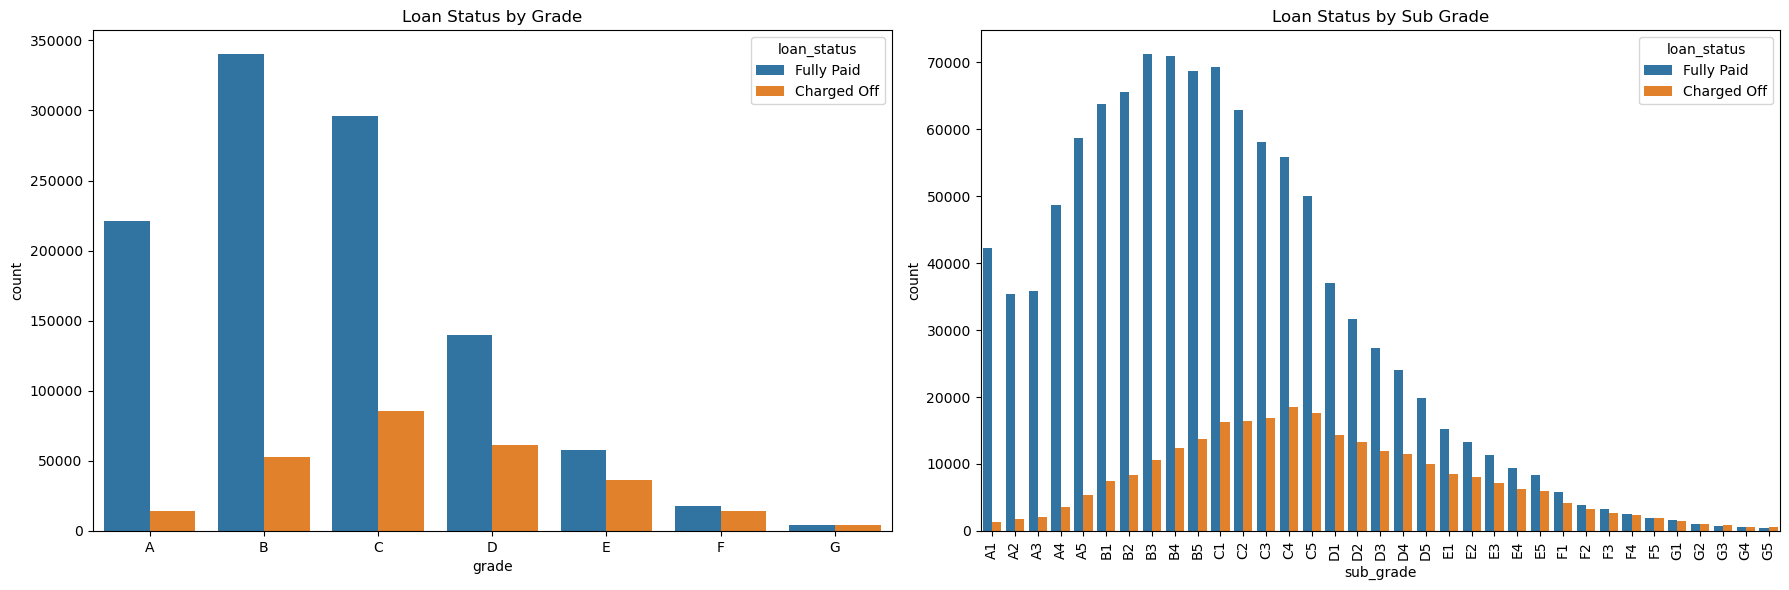

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grade_order = sorted(data.grade.unique().tolist())
sns.countplot(x='grade', data=data, hue='loan_status', order=grade_order, ax=axes[0])
axes[0].set_title("Loan Status by Grade")

sub_grade_order = sorted(data.sub_grade.unique().tolist())
g = sns.countplot(x='sub_grade', data=data, hue='loan_status', order=sub_grade_order, ax=axes[1])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[1].set_title("Loan Status by Sub Grade")

plt.tight_layout()
plt.show()

It looks like `F` and `G` subgrades don't get paid back that often. Let's isolate those and recreate the countplot just for those subgrades.

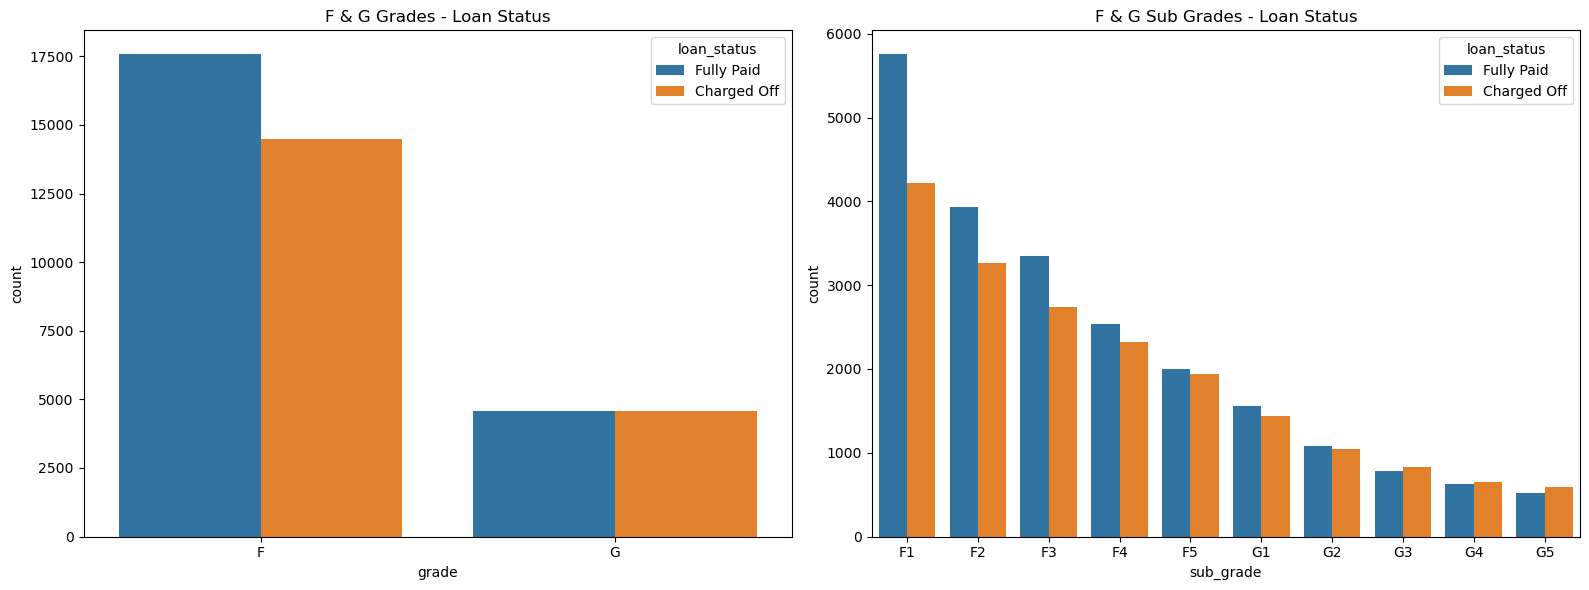

In [12]:
df_fg = data[(data.grade == 'F') | (data.grade == 'G')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

grade_order = sorted(df_fg.grade.unique().tolist())
sns.countplot(x='grade', data=df_fg, hue='loan_status', order=grade_order, ax=axes[0])
axes[0].set_title("F & G Grades - Loan Status")

sub_grade_order = sorted(df_fg.sub_grade.unique().tolist())
sns.countplot(x='sub_grade', data=df_fg, hue='loan_status', order=sub_grade_order, ax=axes[1])
axes[1].set_title("F & G Sub Grades - Loan Status")

plt.tight_layout()
plt.show()

## `term`, `home_ownership`, `verification_status` & `purpose`

> - `term`: The number of payments on the loan. Values are in months and can be either 36 or 60.
> - `home_ownership`: The home ownership status provided by the borrower during registration.
> - `verification_status`: Indicates if income was verified by LC, not verified, or if the income source was verified.
> - `purpose`: A category provided by the borrower for the loan request.

In [13]:
data['home_ownership'].value_counts()

home_ownership
MORTGAGE    665579
RENT        534421
OWN         144832
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64

In [14]:
# Merge ANY and NONE into OTHER
data.loc[(data.home_ownership == 'ANY') | (data.home_ownership == 'NONE'), 'home_ownership'] = 'OTHER'
data.home_ownership.value_counts()

home_ownership
MORTGAGE    665579
RENT        534421
OWN         144832
OTHER          478
Name: count, dtype: int64

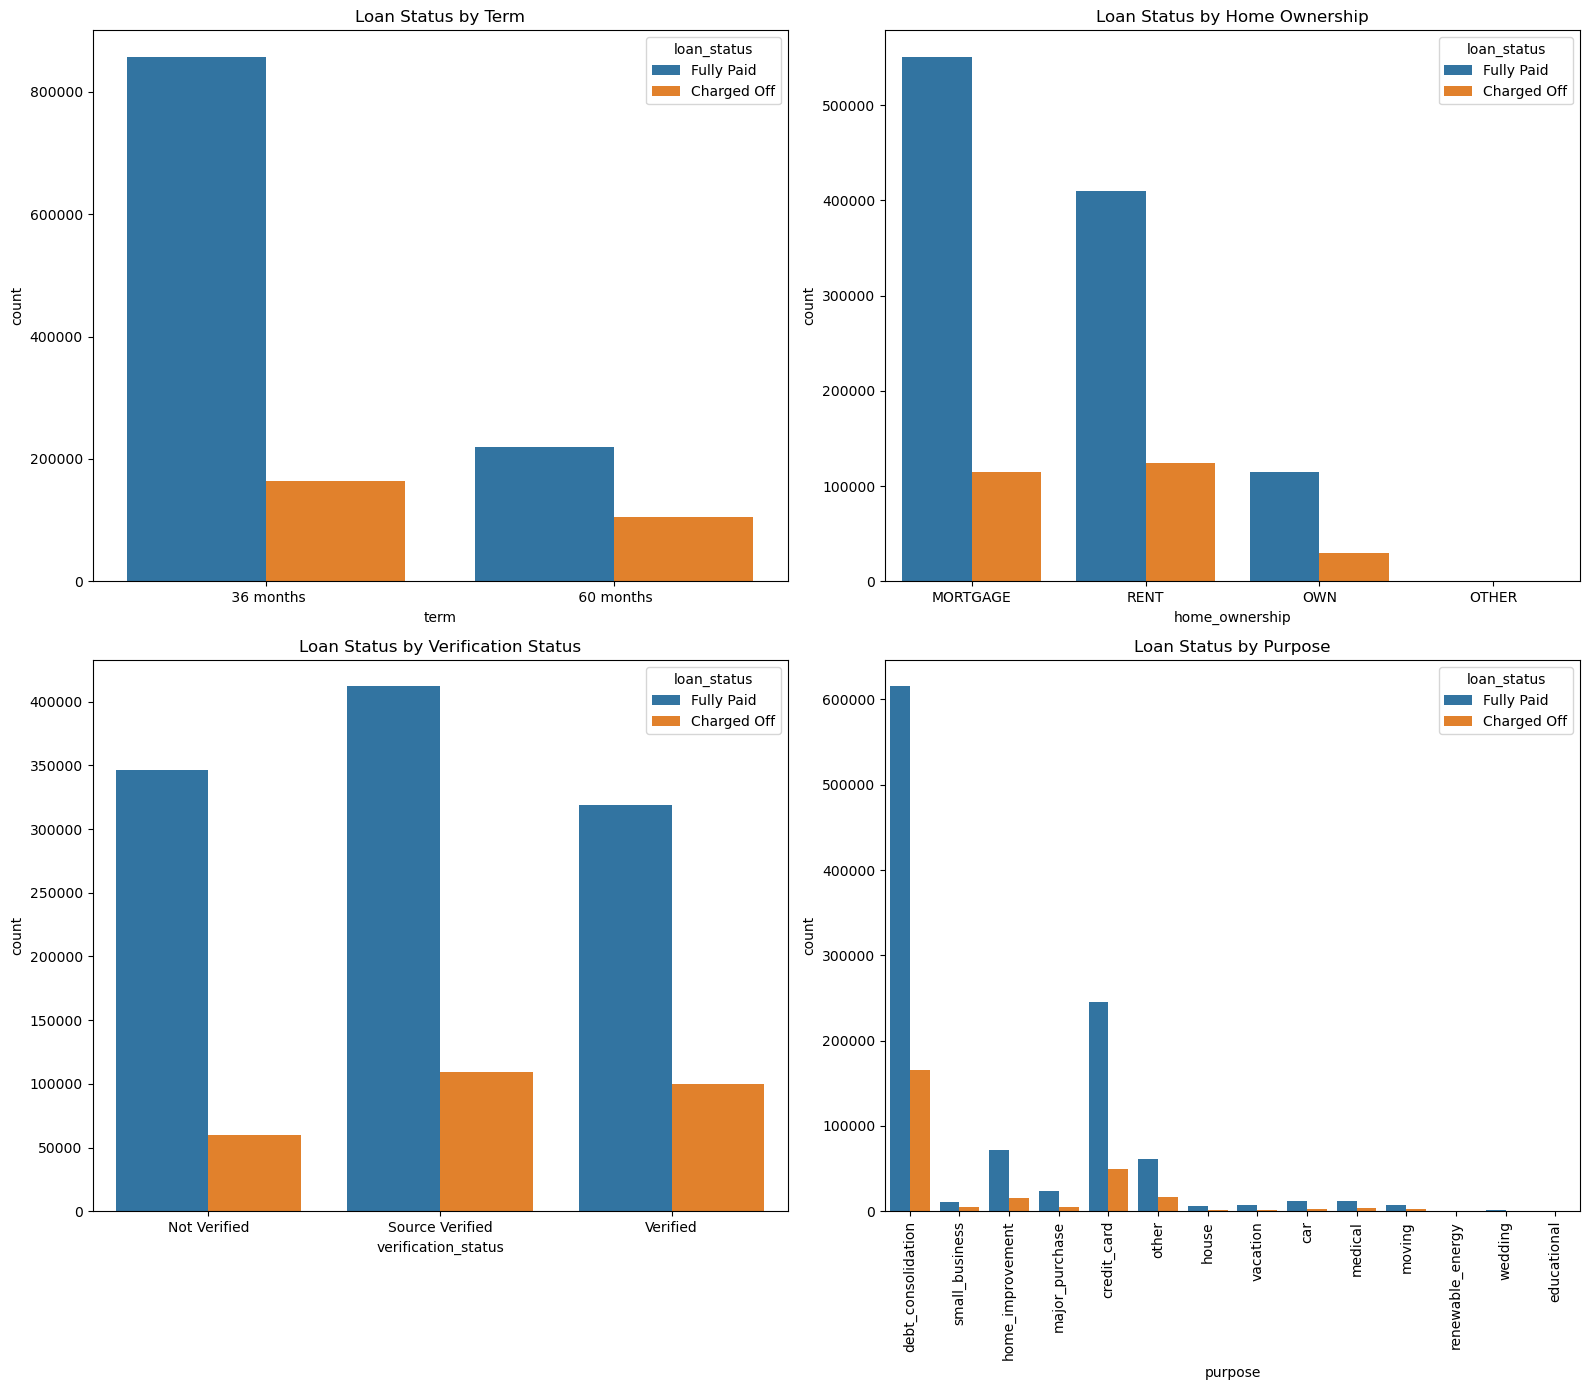

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

sns.countplot(x='term', data=data, hue='loan_status', ax=axes[0, 0])
axes[0, 0].set_title("Loan Status by Term")

sns.countplot(x='home_ownership', data=data, hue='loan_status', ax=axes[0, 1])
axes[0, 1].set_title("Loan Status by Home Ownership")

sns.countplot(x='verification_status', data=data, hue='loan_status', ax=axes[1, 0])
axes[1, 0].set_title("Loan Status by Verification Status")

g = sns.countplot(x='purpose', data=data, hue='loan_status', ax=axes[1, 1])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[1, 1].set_title("Loan Status by Purpose")

plt.tight_layout()
plt.show()

In [16]:
data.loc[data['home_ownership'] == 'OTHER', 'loan_status'].value_counts()

loan_status
Fully Paid     388
Charged Off     90
Name: count, dtype: int64

## `int_rate` & `annual_inc`

> - `int_rate`: Interest Rate on the loan
> - `annual_inc`: The self-reported annual income provided by the borrower during registration

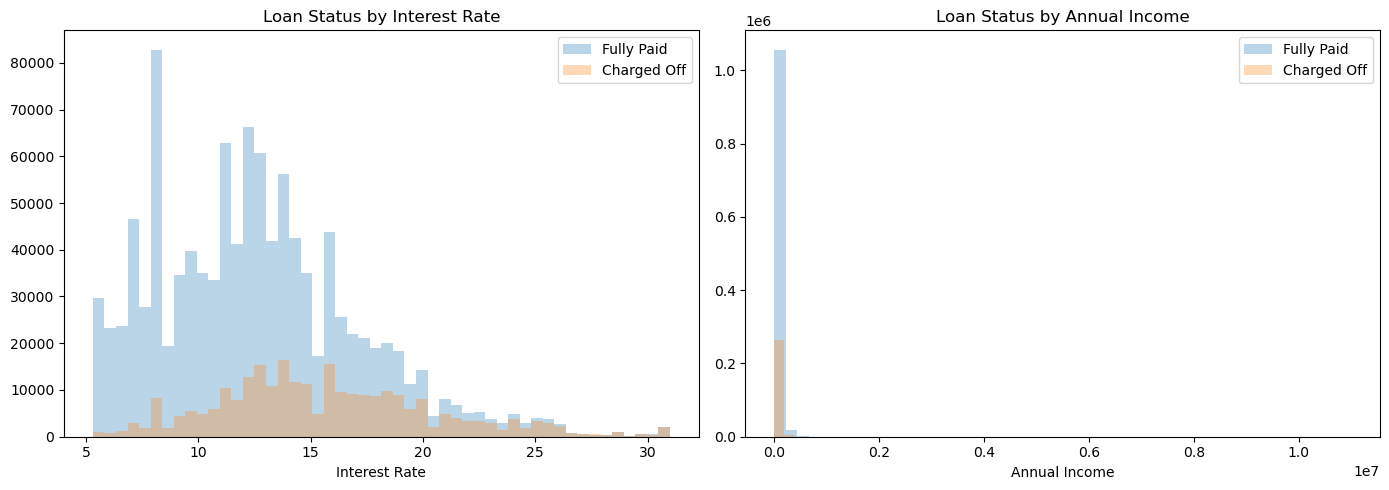

In [17]:
# Handle int_rate if stored as string with '%'
if data['int_rate'].dtype == object:
    data['int_rate'] = data['int_rate'].str.replace('%', '').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['int_rate'], bins=50, alpha=0.3, label=status)
    axes[1].hist(subset['annual_inc'], bins=50, alpha=0.3, label=status)

axes[0].set_title("Loan Status by Interest Rate")
axes[0].set_xlabel("Interest Rate")
axes[0].legend()

axes[1].set_title("Loan Status by Annual Income")
axes[1].set_xlabel("Annual Income")
axes[1].legend()

plt.tight_layout()
plt.show()

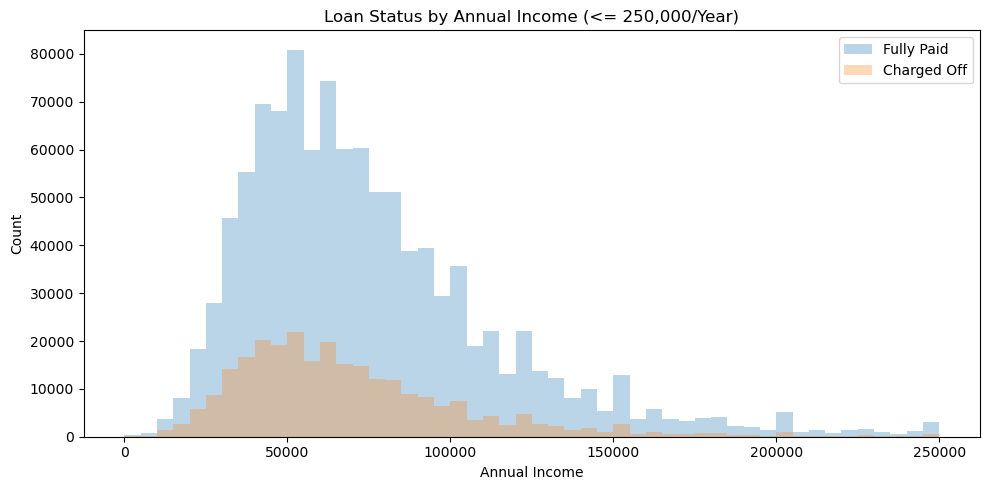

In [18]:
# Zoom in on annual income <= 250,000
fig, ax = plt.subplots(figsize=(10, 5))
for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['annual_inc'] <= 250000)]
    ax.hist(subset['annual_inc'], bins=50, alpha=0.3, label=status)
ax.set_title("Loan Status by Annual Income (<= 250,000/Year)")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
print(f"% with annual_inc >= 250k: {(data[data.annual_inc >= 250000].shape[0] / data.shape[0]) * 100:.4f}%")
print(f"% with annual_inc >= 1M:   {(data[data.annual_inc >= 1000000].shape[0] / data.shape[0]) * 100:.4f}%")

% with annual_inc >= 250k: 1.2252%
% with annual_inc >= 1M:   0.0252%


In [20]:
data.loc[data.annual_inc >= 1000000, 'loan_status'].value_counts()

loan_status
Fully Paid     294
Charged Off     45
Name: count, dtype: int64

In [21]:
data.loc[data.annual_inc >= 250000, 'loan_status'].value_counts()

loan_status
Fully Paid     14269
Charged Off     2214
Name: count, dtype: int64

- It seems that loans with high interest rate are more likely to be unpaid.
- Only a small fraction of borrowers have an annual income more than 1 million.

## `emp_title` & `emp_length`

> - `emp_title`: The job title supplied by the Borrower when applying for the loan.
> - `emp_length`: Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.

In [22]:
print(f"Missing emp_title: {data.emp_title.isna().sum()}")
print(f"Unique emp_title: {data.emp_title.nunique()}")

Missing emp_title: 85785
Unique emp_title: 378353


In [23]:
data['emp_title'].value_counts()[:20]

emp_title
Teacher               21268
Manager               19470
Owner                 10302
Registered Nurse       8774
RN                     8522
Supervisor             8289
Driver                 7558
Sales                  7487
Project Manager        6381
Office Manager         5526
General Manager        5191
Director               5032
owner                  4585
manager                4511
Engineer               4294
President              4162
teacher                4094
Vice President         3539
driver                 3514
Operations Manager     3457
Name: count, dtype: int64

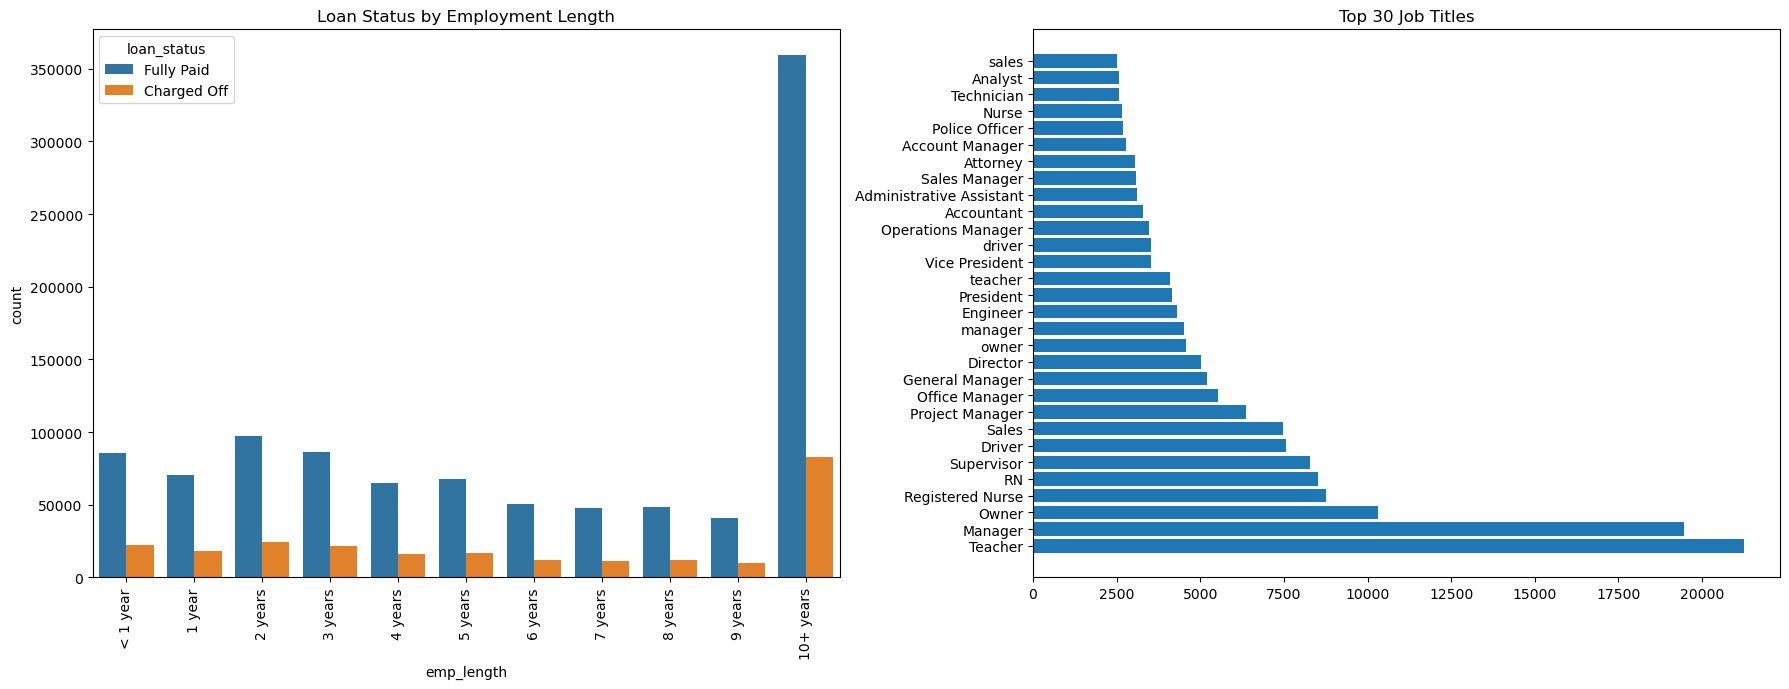

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
         '6 years', '7 years', '8 years', '9 years', '10+ years']
g = sns.countplot(x='emp_length', data=data, hue='loan_status', order=order, ax=axes[0])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[0].set_title("Loan Status by Employment Length")

axes[1].barh(data.emp_title.value_counts()[:30].index, data.emp_title.value_counts()[:30])
axes[1].set_title("Top 30 Job Titles")

plt.tight_layout()
plt.show()

## `issue_d`, `earliest_cr_line`

> - `issue_d`: The month which the loan was funded
> - `earliest_cr_line`: The month the borrower's earliest reported credit line was opened

In [25]:
data['issue_d'] = pd.to_datetime(data['issue_d'])
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])

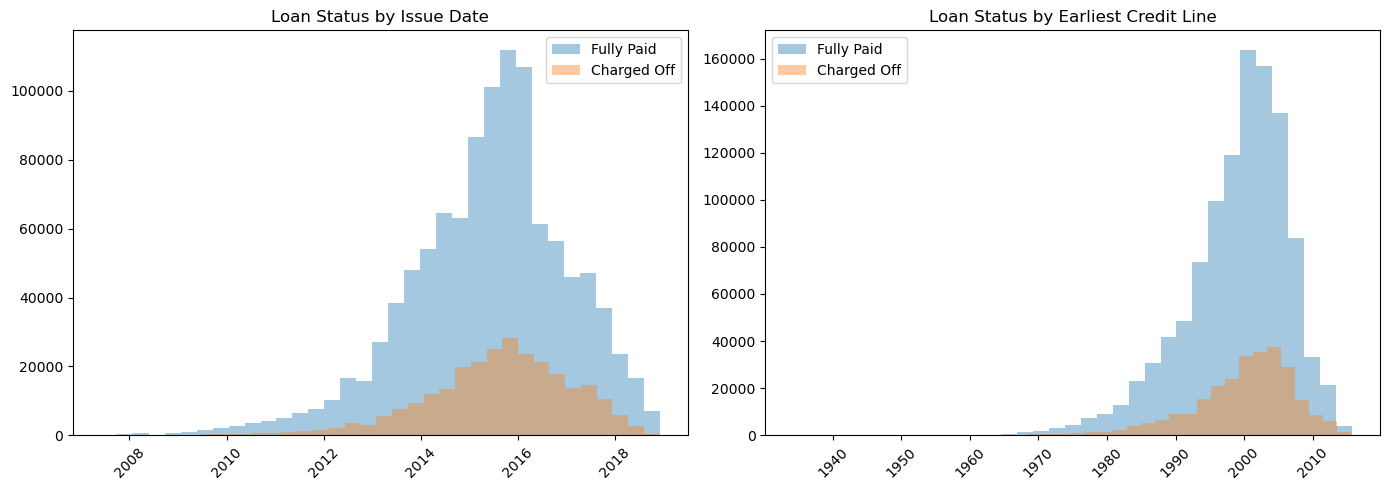

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['issue_d'].dropna(), bins=35, alpha=0.4, label=status)
    axes[1].hist(subset['earliest_cr_line'].dropna(), bins=35, alpha=0.4, label=status)

axes[0].set_title("Loan Status by Issue Date")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].set_title("Loan Status by Earliest Credit Line")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## `title`

> - `title`: The loan title provided by the borrower

In [27]:
print(f"Missing titles: {data.title.isna().sum()}")

Missing titles: 16660


In [28]:
data['title'] = data.title.str.lower()
data.title.value_counts()[:10]

title
debt consolidation         682107
credit card refinancing    250295
home improvement            77604
other                       66862
major purchase              24334
medical expenses            13681
business                    11843
car financing               11245
vacation                     8233
moving and relocation        7952
Name: count, dtype: int64

`title` will be removed because we have the `purpose` column which is generated from it.

## `dti`, `open_acc`, `revol_bal`, `revol_util`, & `total_acc`

> - `dti`: A ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower's self-reported monthly income.
> - `open_acc`: The number of open credit lines in the borrower's credit file.
> - `revol_bal`: Total credit revolving balance
> - `revol_util`: Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
> - `total_acc`: The total number of credit lines currently in the borrower's credit file

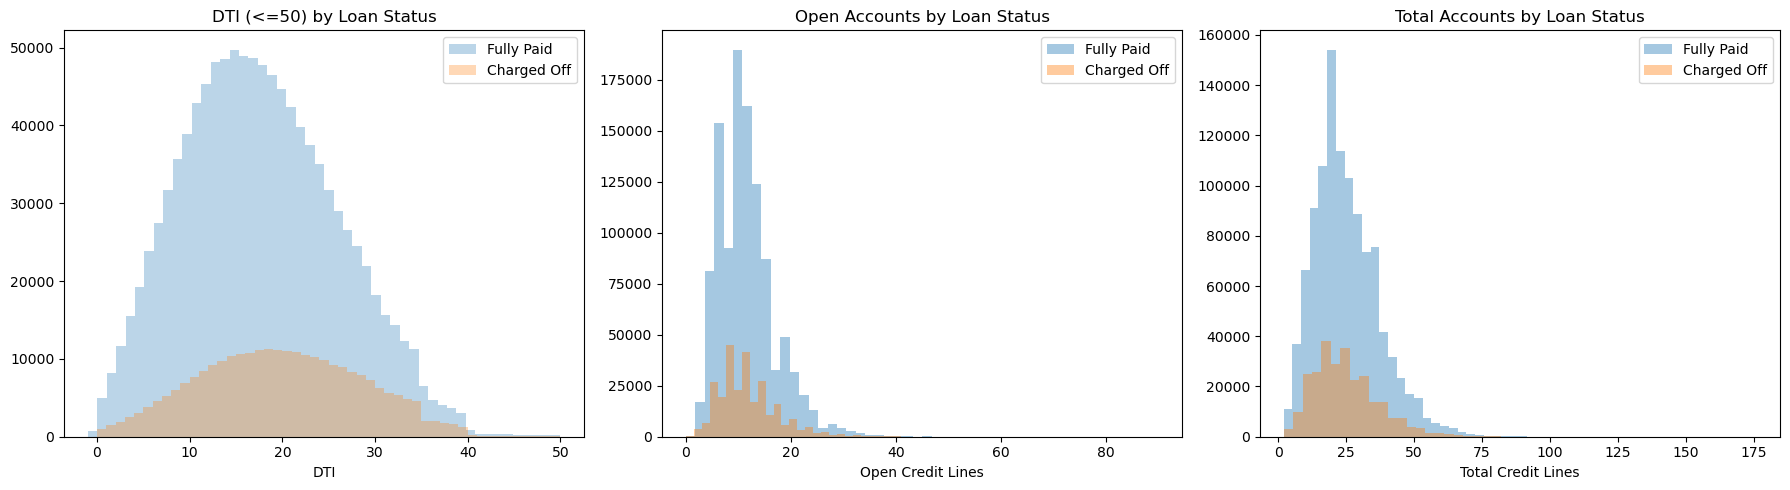

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['dti'] <= 50)]
    axes[0].hist(subset['dti'], bins=50, alpha=0.3, label=status)
axes[0].set_title("DTI (<=50) by Loan Status")
axes[0].set_xlabel("DTI")
axes[0].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[1].hist(subset['open_acc'], bins=50, alpha=0.4, label=status)
axes[1].set_title("Open Accounts by Loan Status")
axes[1].set_xlabel("Open Credit Lines")
axes[1].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[2].hist(subset['total_acc'], bins=50, alpha=0.4, label=status)
axes[2].set_title("Total Accounts by Loan Status")
axes[2].set_xlabel("Total Credit Lines")
axes[2].legend()

plt.tight_layout()
plt.show()

In [30]:
print(f"Total rows: {data.shape[0]}")
print(f"dti >= 40: {data[data['dti'] >= 40].shape[0]}")
print(f"open_acc > 40: {data[data.open_acc > 40].shape[0]}")
print(f"total_acc > 80: {data[data.total_acc > 80].shape[0]}")
print(f"revol_util > 120: {data[data.revol_util > 120].shape[0]}")
print(f"revol_bal > 250000: {data[data.revol_bal > 250000].shape[0]}")

Total rows: 1345310
dti >= 40: 6770
open_acc > 40: 1211
total_acc > 80: 1299
revol_util > 120: 118
revol_bal > 250000: 1594


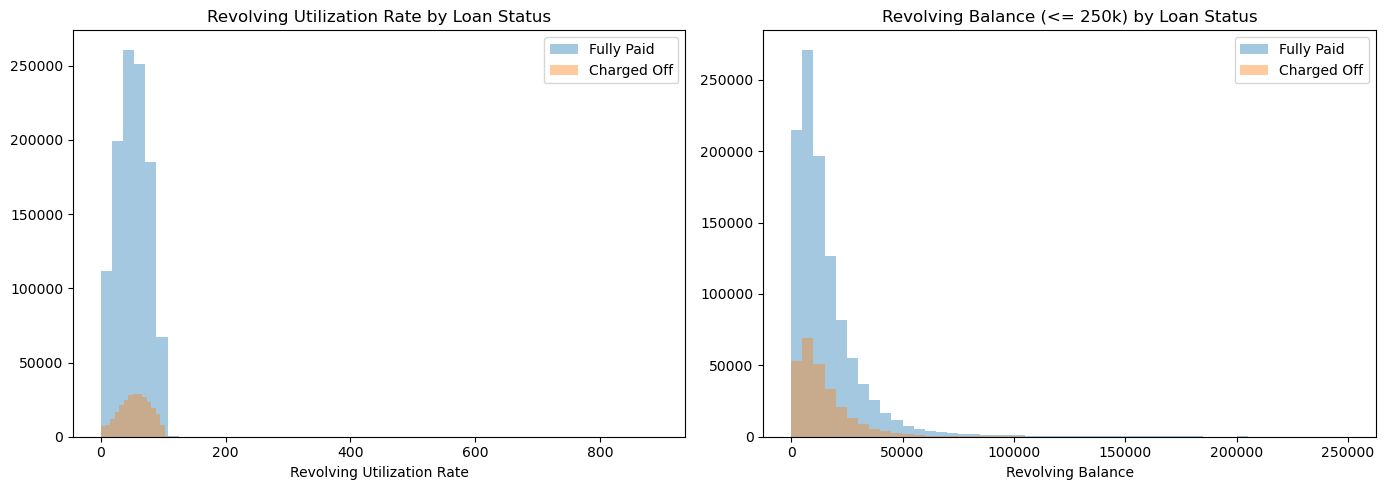

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['revol_util'].dropna(), bins=50, alpha=0.4, label=status)
axes[0].set_title("Revolving Utilization Rate by Loan Status")
axes[0].set_xlabel("Revolving Utilization Rate")
axes[0].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['revol_bal'] <= 250000)]
    axes[1].hist(subset['revol_bal'], bins=50, alpha=0.4, label=status)
axes[1].set_title("Revolving Balance (<= 250k) by Loan Status")
axes[1].set_xlabel("Revolving Balance")
axes[1].legend()

plt.tight_layout()
plt.show()

- It seems that the smaller the `dti` the more likely that the loan will not be paid.
- Only a few hundred borrowers have more than 40 open credit lines.
- Only a few hundred borrowers have more than 80 total credit lines.

## `pub_rec`, `initial_list_status`, `application_type`, `mort_acc`, & `pub_rec_bankruptcies`

> - `pub_rec`: Number of derogatory public records
> - `initial_list_status`: The initial listing status of the loan. Possible values are W, F
> - `application_type`: Indicates whether the loan is an individual application or a joint application with two co-borrowers
> - `mort_acc`: Number of mortgage accounts
> - `pub_rec_bankruptcies`: Number of public record bankruptcies

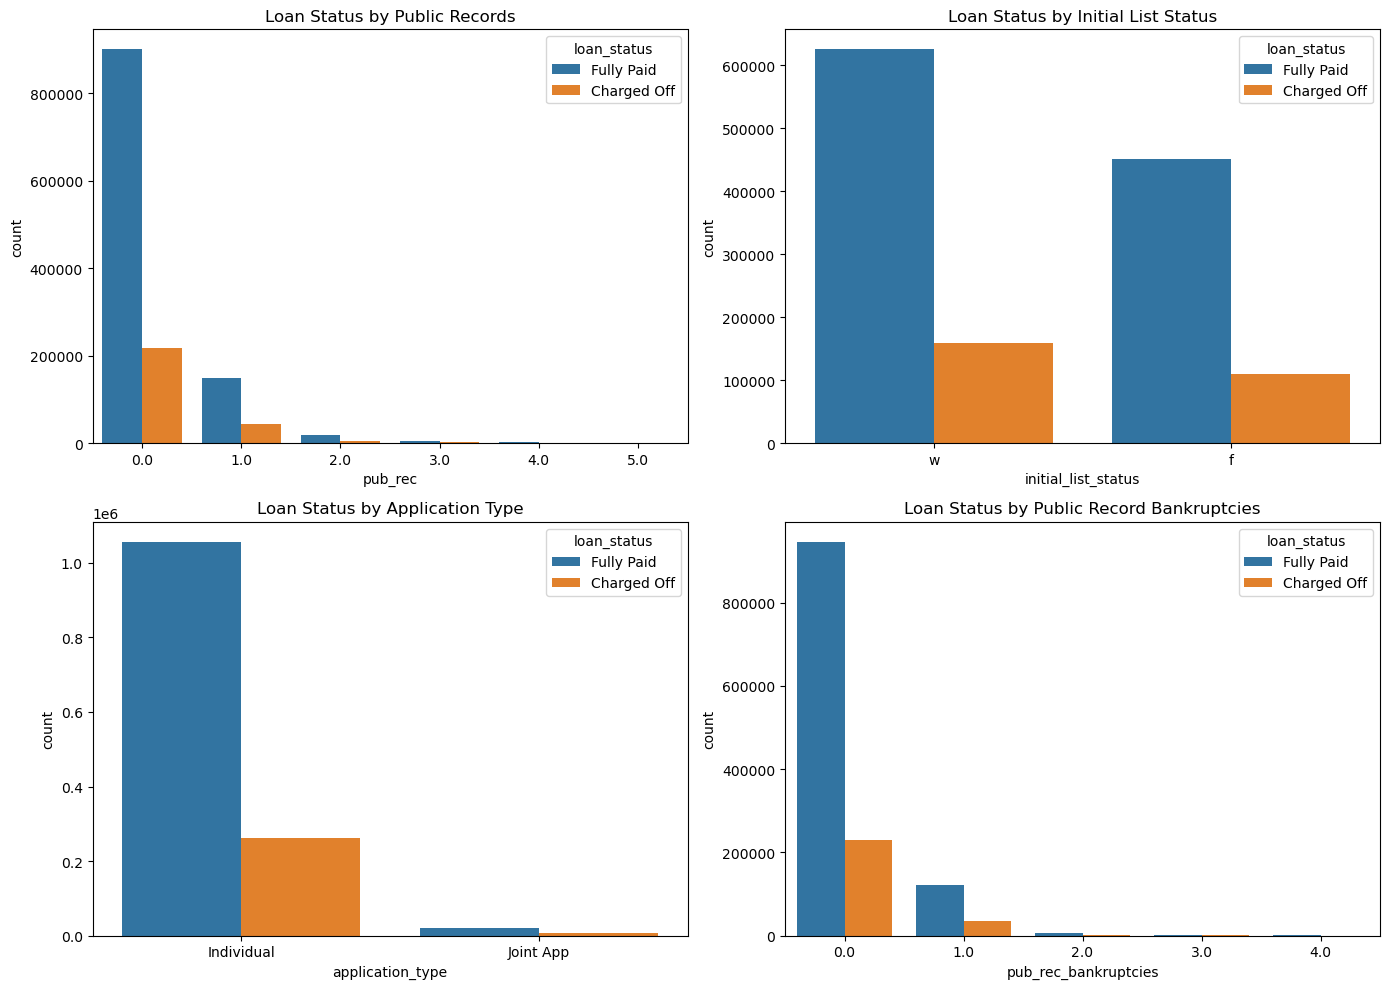

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='pub_rec', data=data[data.pub_rec <= 5], hue='loan_status', ax=axes[0, 0])
axes[0, 0].set_title("Loan Status by Public Records")

sns.countplot(x='initial_list_status', data=data, hue='loan_status', ax=axes[0, 1])
axes[0, 1].set_title("Loan Status by Initial List Status")

sns.countplot(x='application_type', data=data, hue='loan_status', ax=axes[1, 0])
axes[1, 0].set_title("Loan Status by Application Type")

sns.countplot(x='pub_rec_bankruptcies', data=data[data.pub_rec_bankruptcies <= 4], hue='loan_status', ax=axes[1, 1])
axes[1, 1].set_title("Loan Status by Public Record Bankruptcies")

plt.tight_layout()
plt.show()

In [33]:
# Binarize pub_rec, mort_acc, pub_rec_bankruptcies
def binarize(number):
    if number == 0.0:
        return 0
    else:
        return 1

data['pub_rec'] = data.pub_rec.apply(binarize)
data['mort_acc'] = data.mort_acc.apply(binarize)
data['pub_rec_bankruptcies'] = data.pub_rec_bankruptcies.apply(binarize)

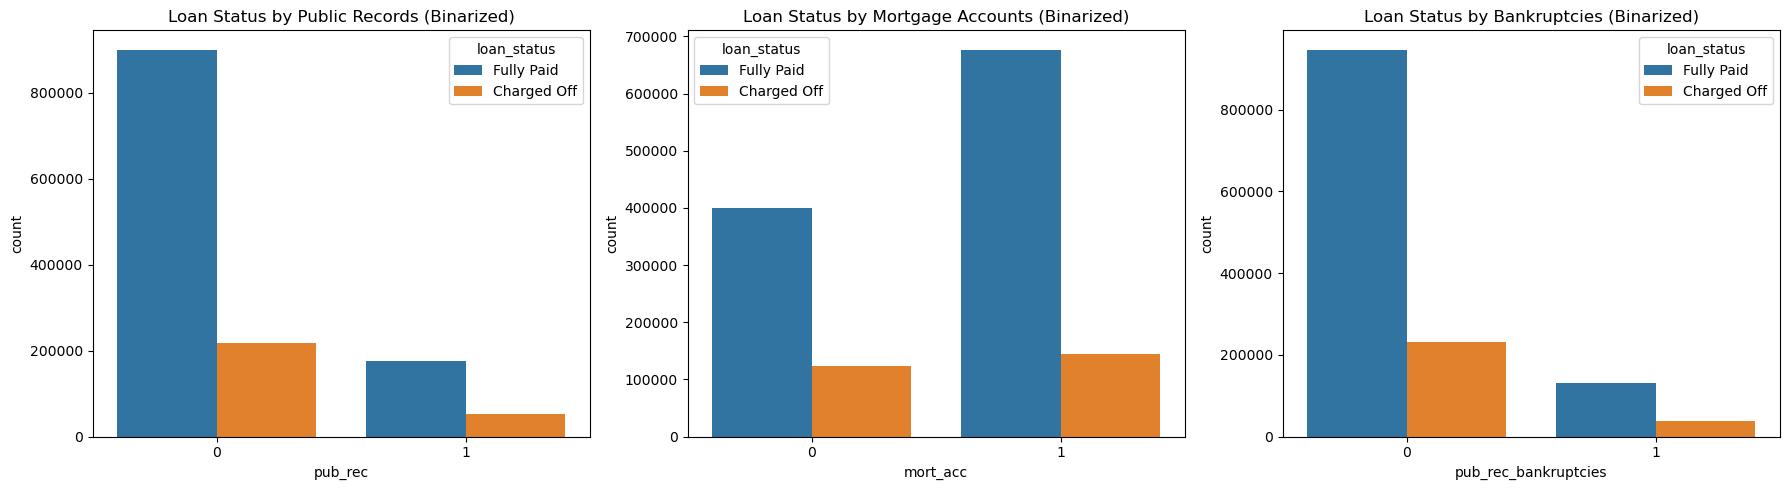

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='pub_rec', data=data, hue='loan_status', ax=axes[0])
axes[0].set_title("Loan Status by Public Records (Binarized)")

sns.countplot(x='mort_acc', data=data, hue='loan_status', ax=axes[1])
axes[1].set_title("Loan Status by Mortgage Accounts (Binarized)")

sns.countplot(x='pub_rec_bankruptcies', data=data, hue='loan_status', ax=axes[2])
axes[2].set_title("Loan Status by Bankruptcies (Binarized)")

plt.tight_layout()
plt.show()

## How numeric features correlate with the target variable?

In [35]:
# Encode loan_status for correlation analysis
data['loan_status'] = data.loan_status.map({'Fully Paid': 1, 'Charged Off': 0})

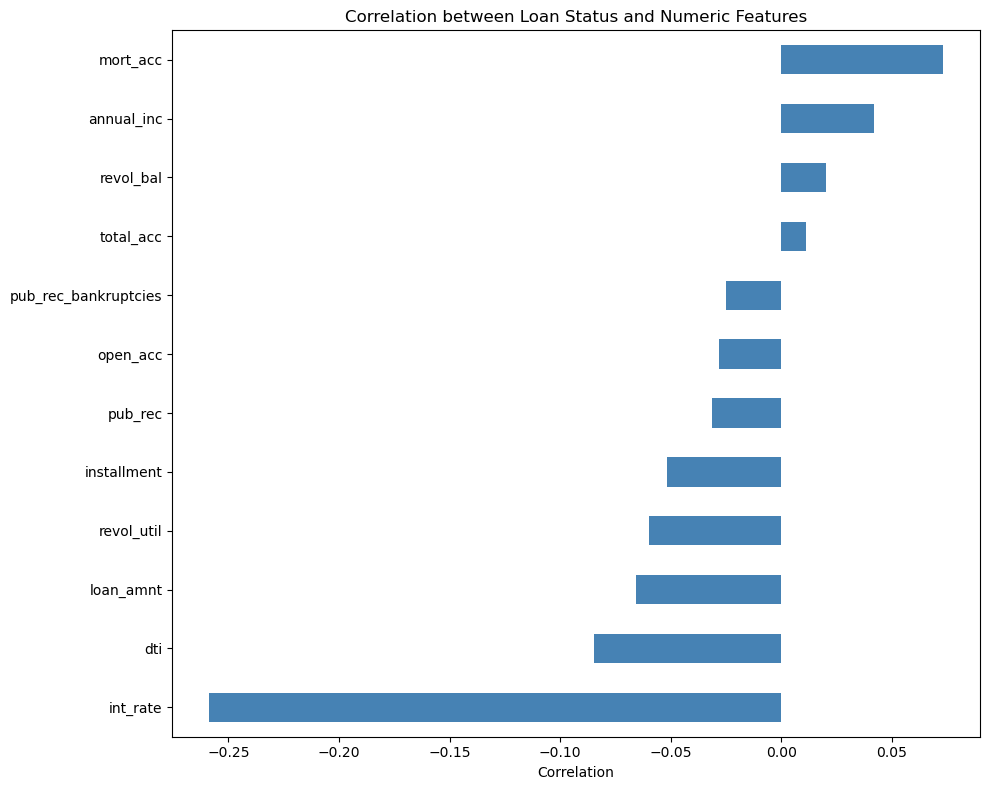

In [36]:
numeric_corr = data.select_dtypes(include=[np.number]).corr()['loan_status'].drop('loan_status').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
numeric_corr.plot.barh(ax=ax, color='steelblue')
ax.set_title("Correlation between Loan Status and Numeric Features")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

## Conclusion

We notice that there are broadly three types of features:
- 1. Features related to the applicant (demographic variables such as age, employment, home ownership, annual income)
- 2. Features related to the loan (loan amount, interest rate, installment, term, grade, purpose)
- 3. Features related to the applicant's credit history (earliest credit line, open accounts, revolving balance, etc.)

In [ ]:
print(f"Final EDA data shape: {data.shape}")